In [1]:
import matplotlib.pyplot as plt

# Diwali Sales Analysis Project

Welcome to the Diwali Sales Analysis project! In this notebook, we will analyze the provided Diwali sales dataset to uncover business insights and trends. The analysis will cover data cleaning, exploratory data analysis, sales breakdowns by various categories, customer demographics, and more. Visualizations will be used throughout to support our findings.

---

**Outline:**
1. Import Required Libraries
2. Load and Inspect the Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Sales Analysis by Product Category
6. Sales Analysis by State and Zone
7. Customer Demographics Analysis
8. Occupation-wise Sales Analysis
9. Top Customers and Products
10. Time Series Analysis (if date available)
11. Data Visualization
12. Export Cleaned Data

Let's get started!

In [2]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
%matplotlib inline

## 2. Load and Inspect the Dataset

Let's load the Diwali Sales Data CSV file and perform an initial inspection to understand its structure.

In [3]:
# Load the dataset
# Use latin1 encoding to handle special characters in the CSV
df = pd.read_csv('Diwali Sales Data.csv', encoding='latin1')

# Display the first 5 rows
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
# Check the shape of the DataFrame
df.shape

(11251, 15)

In [5]:
# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
# Check for missing values
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

## 3. Data Cleaning

Let's clean the data by handling missing values, removing duplicates, and correcting data types where necessary.

In [7]:
# Drop columns with all missing values and unnamed columns
df = df.drop(['Status', 'unnamed1'], axis=1, errors='ignore')

# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values in 'Amount' and 'Orders' columns (drop rows with missing sales info)
df = df.dropna(subset=['Amount', 'Orders'])

# Convert 'Amount' and 'Orders' to numeric (if not already)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df['Orders'] = pd.to_numeric(df['Orders'], errors='coerce')

# Remove rows with missing or zero 'Amount' or 'Orders'
df = df.dropna(subset=['Amount', 'Orders'])
df = df[(df['Amount'] > 0) & (df['Orders'] > 0)]

df.reset_index(drop=True, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11231 entries, 0 to 11230
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11231 non-null  int64  
 1   Cust_name         11231 non-null  object 
 2   Product_ID        11231 non-null  object 
 3   Gender            11231 non-null  object 
 4   Age Group         11231 non-null  object 
 5   Age               11231 non-null  int64  
 6   Marital_Status    11231 non-null  int64  
 7   State             11231 non-null  object 
 8   Zone              11231 non-null  object 
 9   Occupation        11231 non-null  object 
 10  Product_Category  11231 non-null  object 
 11  Orders            11231 non-null  int64  
 12  Amount            11231 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [8]:
# Check for any remaining missing values
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

Let's explore the cleaned dataset with summary statistics and visualizations to understand the data distribution and key characteristics.

In [9]:
# Summary statistics for numerical columns
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123100e+04,11231.000000,11231.000000,11231.000000,11231.000000
mean,1.003004e+06,35.411985,0.419998,2.489093,9454.084982
std,1.716055e+03,12.756116,0.493580,1.114880,5221.728776
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004428e+06,43.000000,1.000000,3.000000,12677.500000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [10]:
# Value counts for categorical columns
cat_cols = ['Gender', 'Age Group', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category']
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for Gender:
Gender
F    7828
M    3403
Name: count, dtype: int64

Value counts for Age Group:
Age Group
26-35    4536
36-45    2282
18-25    1878
46-50     983
51-55     829
55+       427
0-17      296
Name: count, dtype: int64

Value counts for Marital_Status:
Marital_Status
0    6514
1    4717
Name: count, dtype: int64

Value counts for State:
State
Uttar Pradesh       1942
Maharashtra         1522
Karnataka           1304
Delhi               1104
Madhya Pradesh       921
Andhra Pradesh       811
Himachal Pradesh     608
Kerala               453
Haryana              451
Bihar                433
Gujarat              426
Jharkhand            380
Uttarakhand          320
Rajasthan            231
Punjab               200
Telangana            125
Name: count, dtype: int64

Value counts for Zone:
Zone
Central     4287
Southern    2693
Western     1948
Northern    1490
Eastern      813
Name: count, dtype: int64

Value counts for Occupation:
Occupation
IT Sector          1581
H

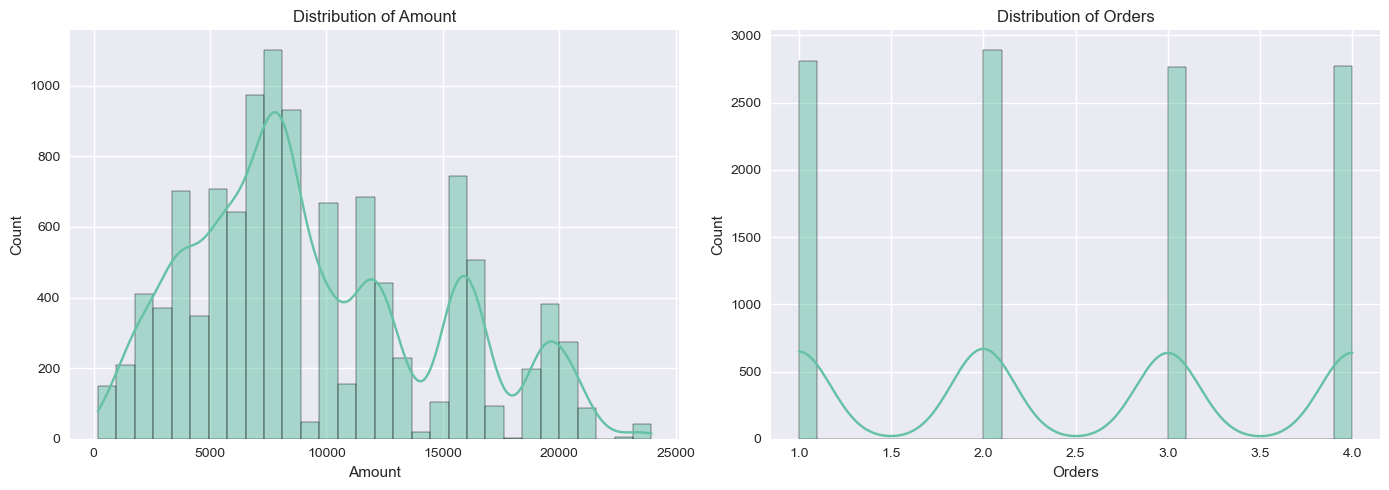

In [11]:
# Distribution of 'Amount' and 'Orders'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Amount'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Amount')
sns.histplot(df['Orders'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Distribution of Orders')
plt.tight_layout()
plt.show()

## 5. Sales Analysis by Product Category

Let's analyze sales performance by product category, including total sales, number of orders, and average order value.

In [12]:
# Group by Product_Category
cat_sales = df.groupby('Product_Category').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False)
cat_sales['Avg_Order_Value'] = cat_sales['Amount'] / cat_sales['Orders']
cat_sales.reset_index(inplace=True)
cat_sales

,Product_Category,Amount,Orders,Avg_Order_Value
0,Food,33933883.50,6110,5553.827087
1,Clothing & Apparel,16484472.00,6627,2487.471254
2,Electronics & Gadgets,15607657.00,5208,2996.861943
3,Footwear & Shoes,15575209.45,2646,5886.322543
4,Furniture,5440051.99,889,6119.293577
5,Games & Toys,4331694.00,940,4608.185106
6,Sports Products,3635933.00,870,4179.233333
7,Beauty,1959484.00,1086,1804.313076
8,Auto,1935041.99,238,8130.428529
9,Stationery,1676051.50,281,5964.596085


<Axes: xlabel='Amount', ylabel='Product_Category'>

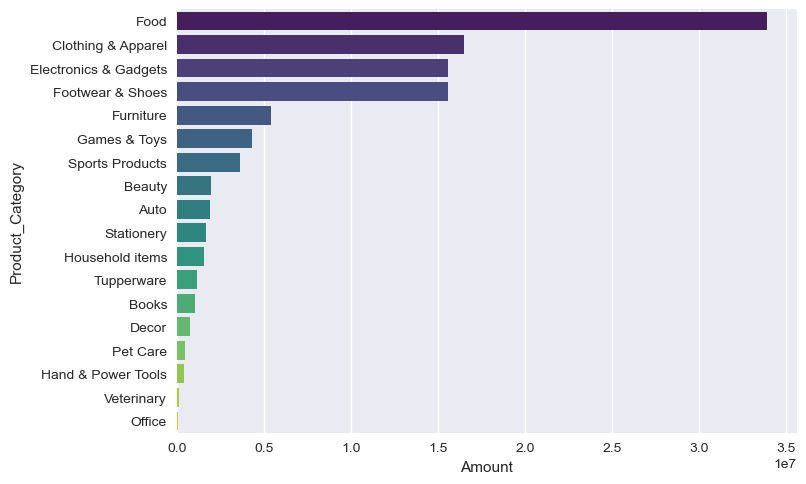

In [13]:
# Ensure df is loaded before using it
import pandas as pd
import seaborn as sns

# Load the dataset if not already loaded
try:
    df
except NameError:
    df = pd.read_csv('Diwali Sales Data.csv', encoding='latin1')

cat_sales = df.groupby('Product_Category').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False)
cat_sales['Avg_Order_Value'] = cat_sales['Amount'] / cat_sales['Orders']
cat_sales.reset_index(inplace=True)

sns.barplot(x='Amount', y='Product_Category', data=cat_sales, palette='viridis', hue='Product_Category', legend=False)

## 6. Sales Analysis by State and Zone

Now, let's analyze sales performance across different states and zones to identify top-performing regions.

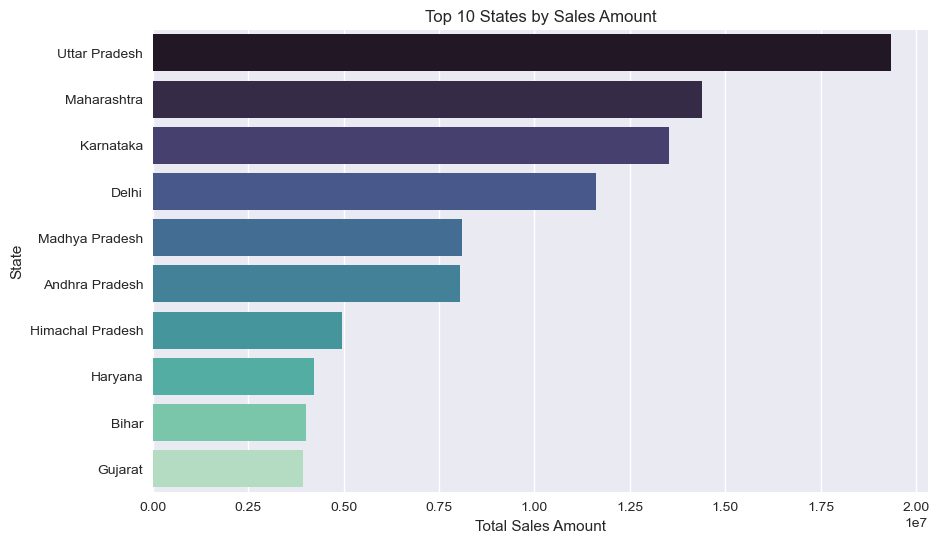

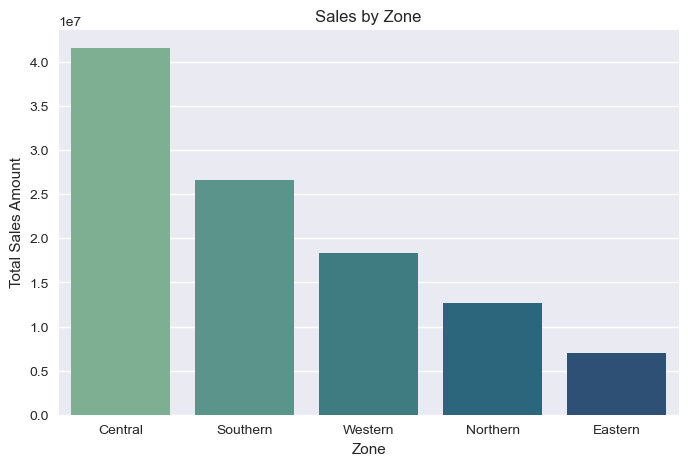

In [14]:
# Ensure matplotlib.pyplot is imported before using plt
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by State
top_states = df.groupby('State').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_states['Amount'], y=top_states.index, palette='mako', hue=top_states.index, legend=False)
plt.title('Top 10 States by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('State')
plt.show()

# Sales by Zone
zone_sales = df.groupby('Zone').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=zone_sales.index, y=zone_sales['Amount'], palette='crest', hue=zone_sales.index, legend=False)
plt.title('Sales by Zone')
plt.xlabel('Zone')
plt.ylabel('Total Sales Amount')
plt.show()

## 7. Customer Demographics Analysis

Let's analyze sales by gender, age group, and marital status to understand customer demographics.

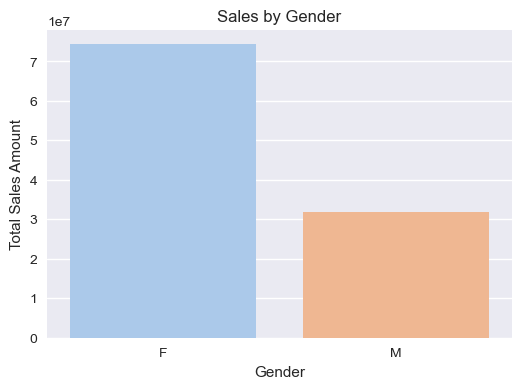

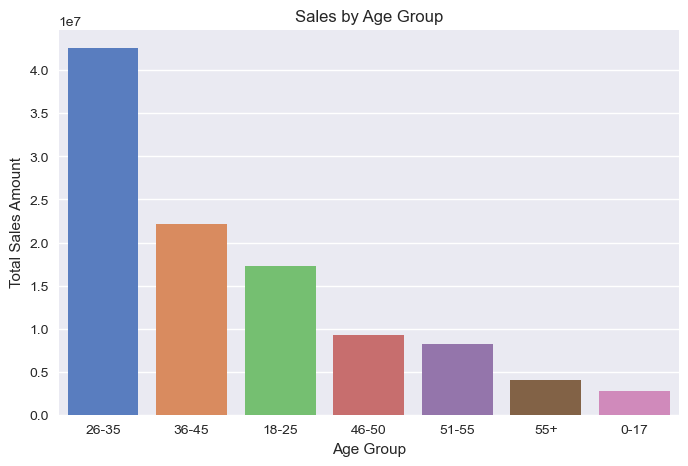

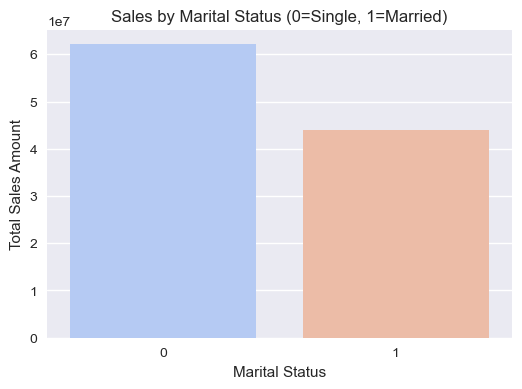

In [15]:
# Sales by Gender
gender_sales = df.groupby('Gender').agg({'Amount': 'sum', 'Orders': 'sum'})
plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index, y=gender_sales['Amount'], palette='pastel', hue=gender_sales.index, legend=False)
plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales Amount')
plt.show()

# Sales by Age Group
age_sales = df.groupby('Age Group').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=age_sales.index, y=age_sales['Amount'], palette='muted', hue=age_sales.index, legend=False)
plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Amount')
plt.show()

# Sales by Marital Status
marital_sales = df.groupby('Marital_Status').agg({'Amount': 'sum', 'Orders': 'sum'})
plt.figure(figsize=(6,4))
sns.barplot(x=marital_sales.index.astype(str), y=marital_sales['Amount'], palette='coolwarm', hue=marital_sales.index.astype(str), legend=False)
plt.title('Sales by Marital Status (0=Single, 1=Married)')
plt.xlabel('Marital Status')
plt.ylabel('Total Sales Amount')
plt.show()

## 8. Occupation-wise Sales Analysis

Let's analyze which occupations contribute most to sales and order counts.

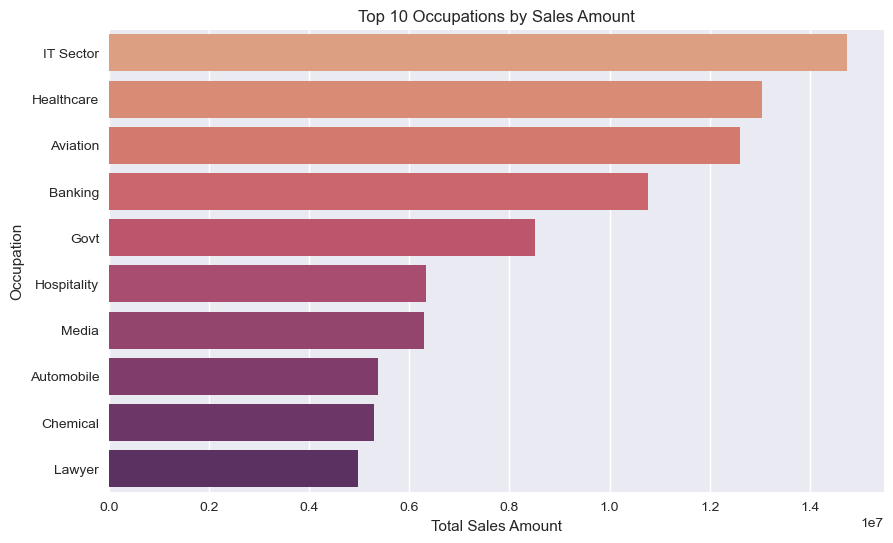

In [16]:
# Top occupations by sales and orders
occ_sales = df.groupby('Occupation').agg({'Amount': 'sum', 'Orders': 'sum'}).sort_values('Amount', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=occ_sales['Amount'], y=occ_sales.index, palette='flare', hue=occ_sales.index, legend=False)
plt.title('Top 10 Occupations by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Occupation')
plt.show()

## 9. Top Customers and Products

Let's identify the top customers by total purchase amount and the top-selling products by order count and revenue.

In [17]:
# Top 10 customers by total purchase amount
top_customers = df.groupby(['User_ID', 'Cust_name']).agg({'Amount': 'sum'}).sort_values('Amount', ascending=False).head(10)
top_customers.reset_index(inplace=True)
top_customers

# Top 10 products by order count
top_products_orders = df.groupby('Product_ID').agg({'Orders': 'sum'}).sort_values('Orders', ascending=False).head(10)
top_products_orders.reset_index(inplace=True)
top_products_orders

# Top 10 products by revenue
top_products_revenue = df.groupby('Product_ID').agg({'Amount': 'sum'}).sort_values('Amount', ascending=False).head(10)
top_products_revenue.reset_index(inplace=True)
top_products_revenue

,Product_ID,Amount
0,P00265242,540136.0
1,P00110942,424833.0
2,P00184942,401816.0
3,P00112142,341020.0
4,P00059442,338571.0
5,P00237542,322363.0
6,P00058042,307040.0
7,P00110742,294548.0
8,P00110842,290661.0
9,P00080342,283309.0


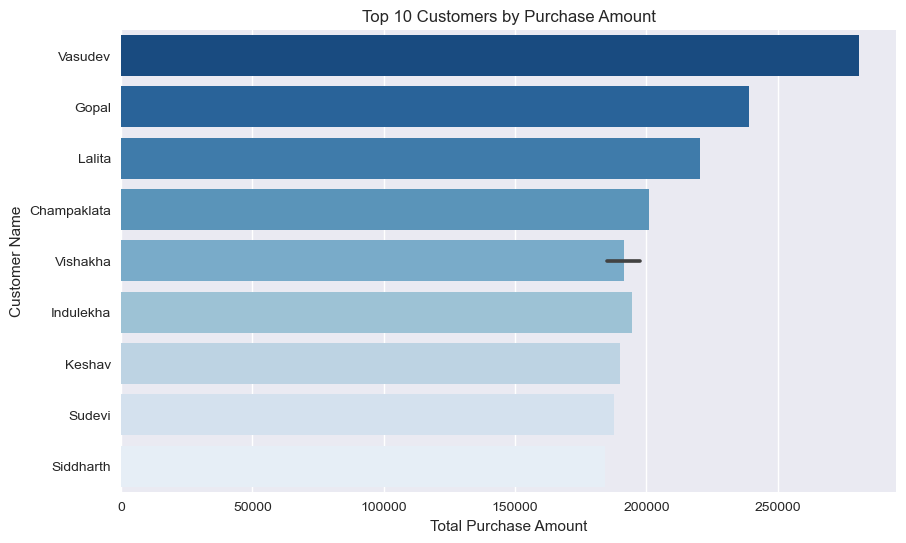

In [18]:
# Visualize top 10 customers by purchase amount
plt.figure(figsize=(10,6))
sns.barplot(x='Amount', y='Cust_name', data=top_customers, palette='Blues_r', hue='Cust_name', legend=False)
plt.title('Top 10 Customers by Purchase Amount')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Customer Name')
plt.show()

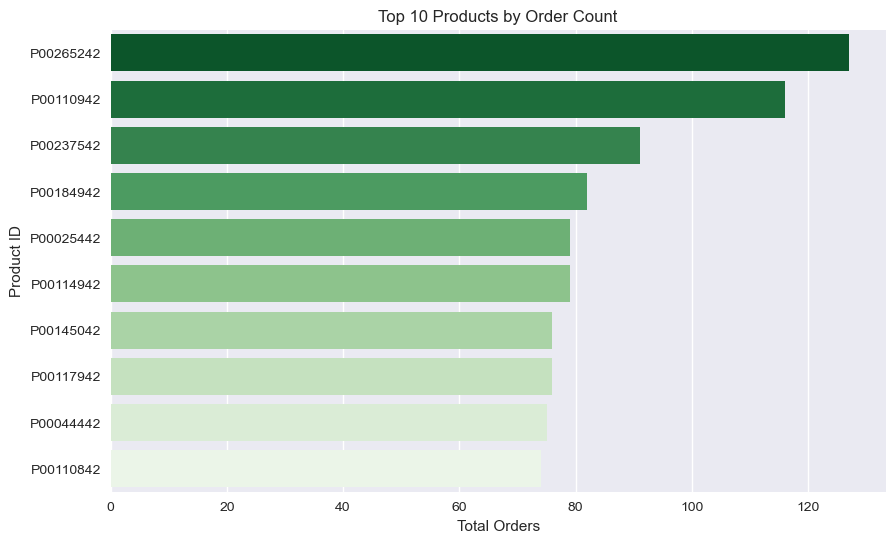

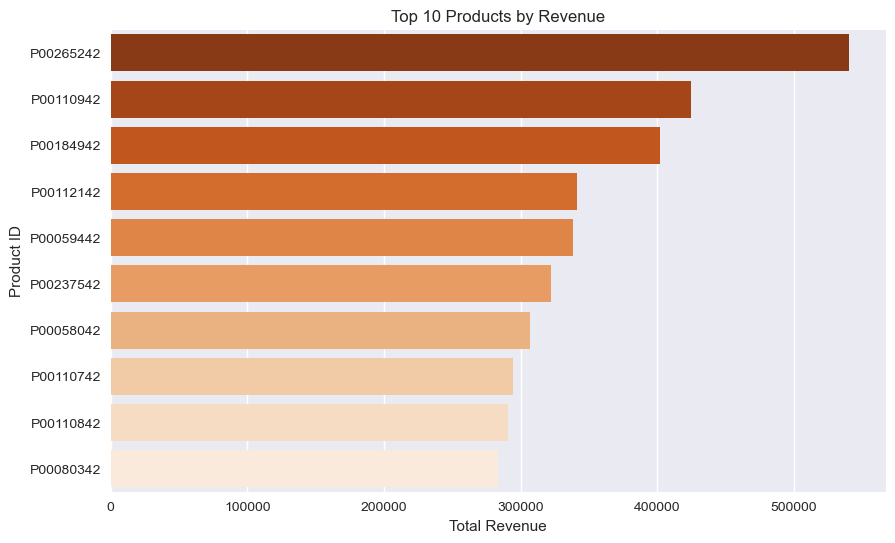

In [19]:
# Visualize top 10 products by order count
plt.figure(figsize=(10,6))
sns.barplot(x='Orders', y='Product_ID', data=top_products_orders, palette='Greens_r', hue='Product_ID', legend=False)
plt.title('Top 10 Products by Order Count')
plt.xlabel('Total Orders')
plt.ylabel('Product ID')
plt.show()

# Visualize top 10 products by revenue
plt.figure(figsize=(10,6))
sns.barplot(x='Amount', y='Product_ID', data=top_products_revenue, palette='Oranges_r', hue='Product_ID', legend=False)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product ID')
plt.show()

## 10. Time Series Analysis

The dataset does not contain a date column, so time series analysis is not applicable for this data.

## 11. Data Visualization

Let's create some additional visualizations to highlight key insights from the analysis.

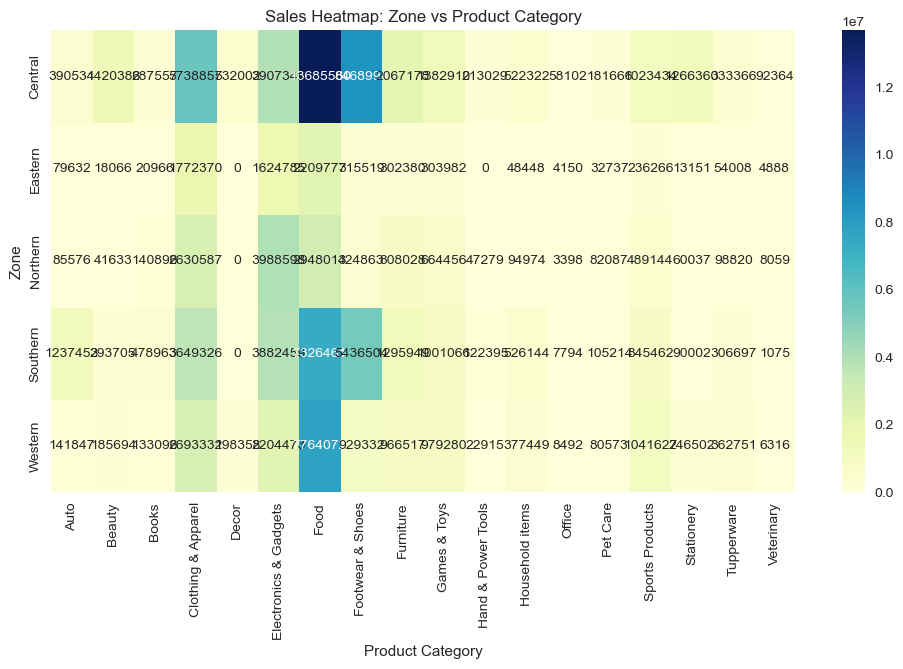

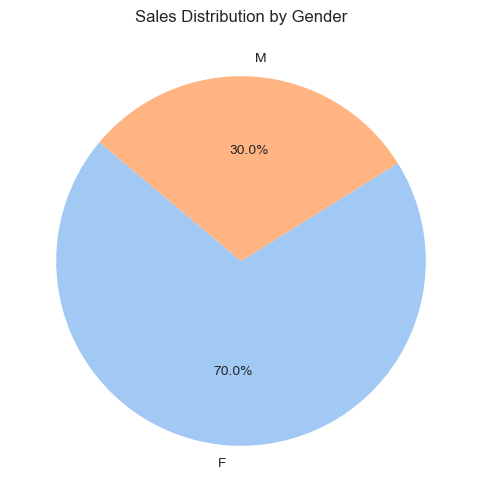

In [20]:
# Heatmap: Sales by Zone and Product Category
pivot = df.pivot_table(index='Zone', columns='Product_Category', values='Amount', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales Heatmap: Zone vs Product Category')
plt.ylabel('Zone')
plt.xlabel('Product Category')
plt.show()

# Pie chart: Sales by Gender
plt.figure(figsize=(6,6))
gender_pie = df.groupby('Gender')['Amount'].sum()
plt.pie(gender_pie, labels=gender_pie.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Sales Distribution by Gender')
plt.show()

## 12. Export Cleaned Data

Let's export the cleaned and processed DataFrame to a new CSV file for future use.

In [21]:
# Export cleaned data to CSV
df.to_csv('Diwali_Sales_Cleaned.csv', index=False)
print('Cleaned data exported to Diwali_Sales_Cleaned.csv')

Cleaned data exported to Diwali_Sales_Cleaned.csv


# Conclusion & Recommendations

- The analysis provided insights into sales trends by product category, state, zone, customer demographics, and occupation.
- Top product categories and states can be targeted for future marketing campaigns.
- Customer segmentation by age, gender, and occupation can help personalize offers.
- The cleaned dataset is now ready for further modeling or business use.

**Thank you for exploring the Diwali Sales Analysis project!**